# O-RAN Traffic Prediction with Autoformer

This notebook reproduces the transformer-based wireless traffic prediction research from Habib et al. (2024).

## Overview

- **Dataset**: Colosseum O-RAN COMMAG dataset
- **Model**: Autoformer architecture (Wu et al.)
- **Goal**: Predict wireless network traffic for proactive RAN optimization

## Notebook Structure

1. Setup and Data Loading
2. Exploratory Data Analysis
3. Data Preprocessing
4. Model Training (Autoformer + Baselines)
5. Evaluation and Comparison
6. Results Visualization

## 1. Setup and Imports

In [ ]:
# Standard library imports
import os
import shutil
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")


# --- Colab vs local: set project_root and optional clone ---
def _is_colab():
    try:
        import google.colab

        return True
    except ImportError:
        return False


if _is_colab():
    from google.colab import drive

    drive.mount("/content/drive", use_metadata_server=False)

    REPO_URL = "https://github.com/thienandangthanh/oran-traffic-prediction.git"
    BRANCH_OR_TAG = "main"
    PROJECT_DIR = "/content/traffic-prediction"
    DRIVE_DATASET_DIR = Path("/content/drive/MyDrive/traffic-prediction/colosseum-oran-commag-dataset")

    if not Path(PROJECT_DIR).exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH_OR_TAG, REPO_URL, PROJECT_DIR], check=True)
    os.chdir(PROJECT_DIR)
    project_root = Path.cwd()

    if DRIVE_DATASET_DIR.exists() and (DRIVE_DATASET_DIR / "slice_traffic").exists():
        dataset_root = DRIVE_DATASET_DIR
        print("Using dataset from Google Drive (skipping clone).")
    else:
        subprocess.run(["git", "submodule", "update", "--init", "--recursive"], check=True)
        dataset_root = project_root / "colosseum-oran-commag-dataset"
        DRIVE_DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
        if not DRIVE_DATASET_DIR.exists():
            print("Copying dataset to Google Drive (one-time, may take a while)...")
            shutil.copytree(dataset_root, DRIVE_DATASET_DIR)
            print("Done. Future runs will use Drive and skip cloning.")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torch",
            "transformers",
            "numpy",
            "pandas",
            "matplotlib",
            "seaborn",
            "scikit-learn",
            "scipy",
            "tqdm",
        ],
        check=True,
    )
    print(f"Colab: project_root = {project_root}, dataset_root = {dataset_root}")
else:
    project_root = Path.cwd().parent
    dataset_root = project_root / "colosseum-oran-commag-dataset"
    print(f"Local: project_root = {project_root}")

sys.path.insert(0, str(project_root / "src"))

# Scientific computing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader

from data.aggregator import TrafficAggregator

# Custom modules
from data.dataset_loader import ColosseumDatasetLoader
from data.preprocessor import TrafficPreprocessor
from models.autoformer_wrapper import AutoformerPredictor, TrafficDataset
from models.baseline_models import LSTMPredictor, MovingAverageModel, PersistenceModel
from utils.metrics import PredictionMetrics
from utils.visualization import TrafficVisualizer

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda


## 2. Data Loading and Exploration

Load the Colosseum O-RAN dataset and explore its structure.

In [2]:
# Initialize dataset loader
dataset_root = project_root / "colosseum-oran-commag-dataset"
loader = ColosseumDatasetLoader(str(dataset_root))

# Get dataset summary
print("=== Dataset Summary ===")
summary = loader.get_dataset_summary(slice_type="slice_traffic")
print(f"Total scenarios: {summary['scenario'].nunique()}")
print(f"Total training configs: {len(summary)}")
print("\nAvailable scenarios:")
print(loader.get_available_scenarios("slice_traffic"))

=== Dataset Summary ===
Total scenarios: 4
Total training configs: 72

Available scenarios:
['rome_slow_close', 'rome_static_close', 'rome_static_far', 'rome_static_medium']


In [3]:
# Load data from rome_static_medium scenario
scenario = "rome_static_medium"
training_configs = ["tr0", "tr1", "tr2"]  # Start with subset for quick testing

print(f"Loading data from scenario: {scenario}")
print(f"Training configs: {training_configs}")

# Load scenario data
data = loader.load_scenario_data(scenario=scenario, training_configs=training_configs, slice_type="slice_traffic")

print(f"\nLoaded {len(data)} rows")
print(f"Columns: {list(data.columns)}")
print(f"\nData shape: {data.shape}")
print("\nFirst few rows:")
data.head()

Loading data from scenario: rome_static_medium
Training configs: ['tr0', 'tr1', 'tr2']

Loaded 107096 rows
Columns: ['time', 'nof_ue', 'dl_brate', 'ul_brate', 'scenario', 'training_config', 'experiment', 'base_station']

Data shape: (107096, 8)

First few rows:


,time,nof_ue,dl_brate,ul_brate,scenario,training_config,experiment,base_station
0,2020-10-16 13:46:13.107,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
1,2020-10-16 13:46:13.357,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
2,2020-10-16 13:46:13.607,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
3,2020-10-16 13:46:13.857,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
4,2020-10-16 13:46:14.107,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1


In [4]:
# Explore data statistics
print("=== Data Statistics ===")
print(f"\nTime range: {data['time'].min()} to {data['time'].max()}")
print(f"Duration: {data['time'].max() - data['time'].min()}")
print(f"\nBase stations: {data['base_station'].unique()}")
print(f"Number of UEs range: {data['nof_ue'].min()} - {data['nof_ue'].max()}")
print("\nDownlink bitrate (Mbps):")
print(f"  Mean: {data['dl_brate'].mean() / 1e6:.2f}")
print(f"  Std: {data['dl_brate'].std() / 1e6:.2f}")
print(f"  Min: {data['dl_brate'].min() / 1e6:.2f}")
print(f"  Max: {data['dl_brate'].max() / 1e6:.2f}")

# Check for missing values
print("\nMissing values:")
print(data.isnull().sum())

=== Data Statistics ===

Time range: 2020-10-16 13:45:18.598000 to 2020-10-18 01:57:50.185000
Duration: 1 days 12:12:31.587000

Base stations: <StringArray>
['bs1', 'bs2', 'bs3', 'bs4']
Length: 4, dtype: str
Number of UEs range: 0.0 - 14.0

Downlink bitrate (Mbps):
  Mean: 1.02
  Std: 0.58
  Min: 0.00
  Max: 2.89

Missing values:
time                0
nof_ue             23
dl_brate           25
ul_brate           43
scenario            0
training_config     0
experiment          0
base_station        0
dtype: int64


### Visualize Traffic Patterns

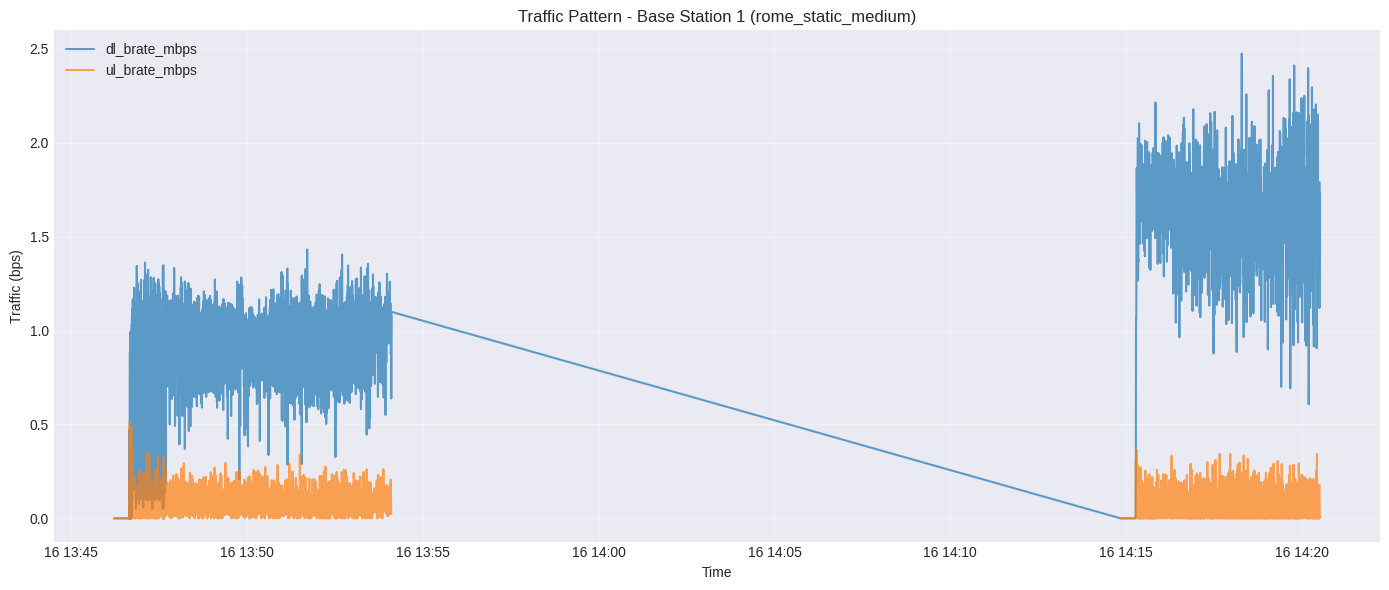

In [5]:
# Visualize traffic over time for one base station
bs1_data = data[data["base_station"] == "bs1"].copy()
bs1_data = bs1_data.sort_values("time").reset_index(drop=True)

# Convert bitrate to Mbps for better readability
bs1_data["dl_brate_mbps"] = bs1_data["dl_brate"] / 1e6
bs1_data["ul_brate_mbps"] = bs1_data["ul_brate"] / 1e6

visualizer = TrafficVisualizer()
visualizer.plot_time_series(
    data=bs1_data.iloc[:5000],  # Plot first 5000 points
    time_column="time",
    value_columns=["dl_brate_mbps", "ul_brate_mbps"],
    title=f"Traffic Pattern - Base Station 1 ({scenario})",
)

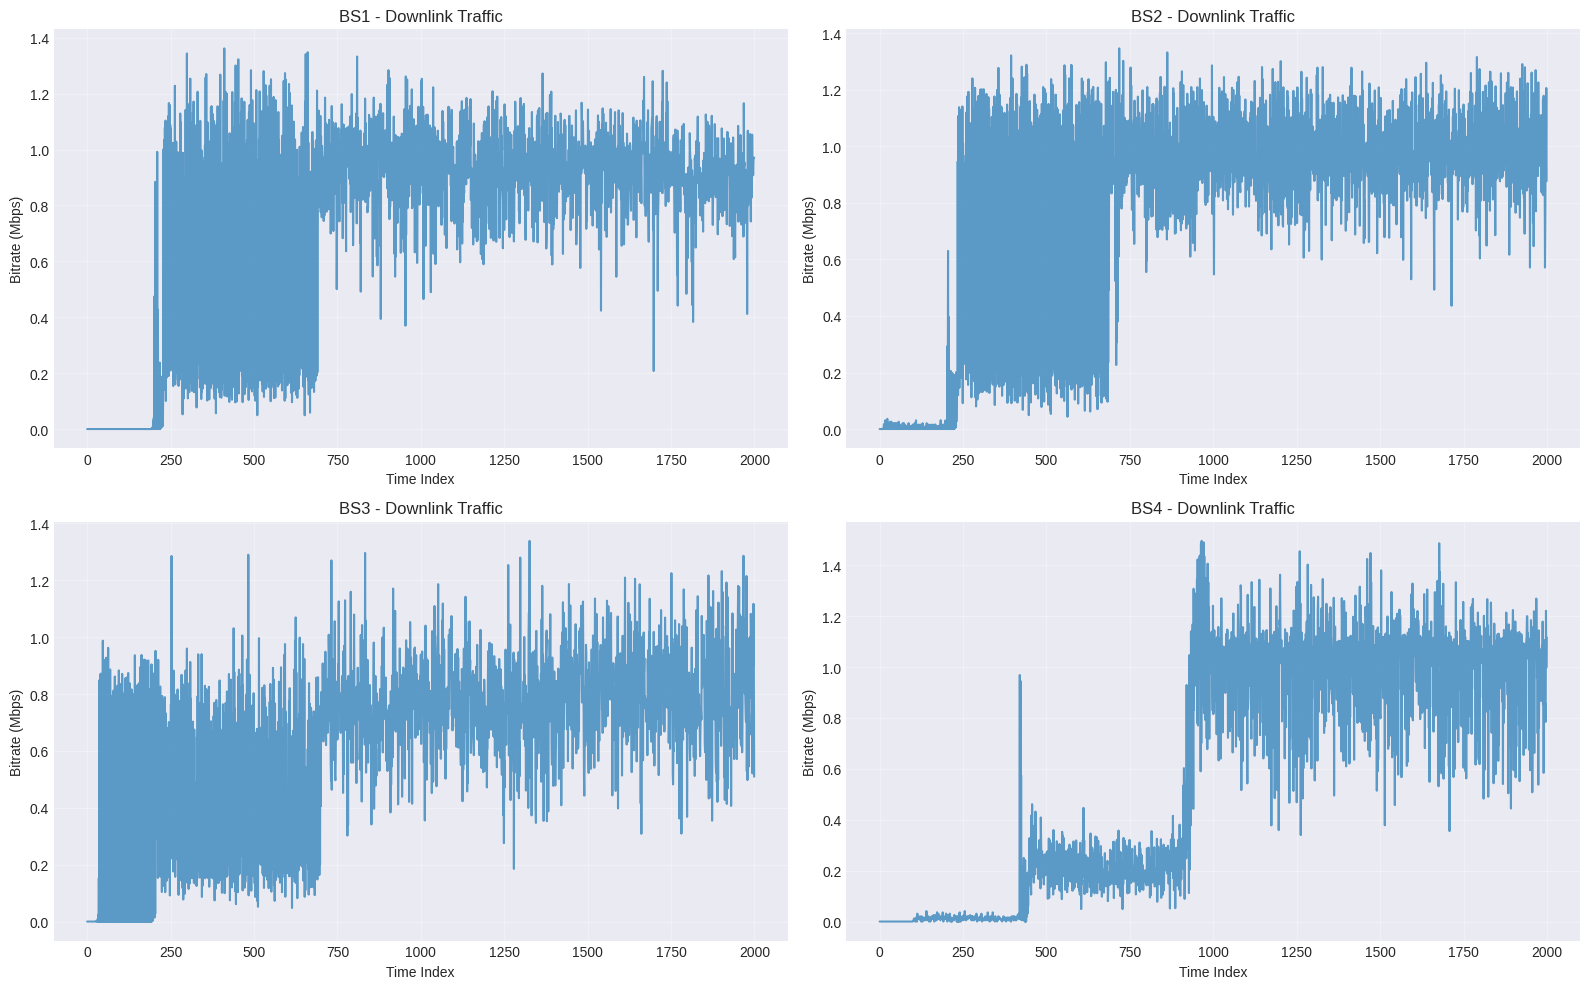

In [6]:
# Compare traffic across base stations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, bs in enumerate(["bs1", "bs2", "bs3", "bs4"]):
    bs_data = data[data["base_station"] == bs].copy()
    bs_data = bs_data.sort_values("time").reset_index(drop=True)
    bs_data["dl_brate_mbps"] = bs_data["dl_brate"] / 1e6

    # Plot subset
    subset = bs_data.iloc[:2000]
    axes[idx].plot(subset.index, subset["dl_brate_mbps"], alpha=0.7)
    axes[idx].set_title(f"{bs.upper()} - Downlink Traffic")
    axes[idx].set_xlabel("Time Index")
    axes[idx].set_ylabel("Bitrate (Mbps)")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

Apply preprocessing steps:
1. Traffic aggregation over time windows
2. Savitzky-Golay smoothing filter
3. Normalization
4. Train/validation/test split

In [7]:
# Focus on one base station for initial experiments
bs_data = data[data["base_station"] == "bs1"].copy()
bs_data = bs_data.sort_values("time").reset_index(drop=True)

print(f"Working with {len(bs_data)} samples from BS1")
print(f"Time range: {bs_data['time'].min()} to {bs_data['time'].max()}")

Working with 27718 samples from BS1
Time range: 2020-10-16 13:46:13.107000 to 2020-10-18 01:57:45.495000


In [8]:
# Step 1: Aggregate traffic over time windows
aggregator = TrafficAggregator(aggregation_window="500ms")

aggregated_data = aggregator.aggregate_traffic(
    data=bs_data,
    time_column="time",
    value_columns=["dl_brate", "ul_brate", "nof_ue"],
    aggregation_func="mean",  # Use mean for smoother patterns
)

print(f"After aggregation: {len(aggregated_data)} samples")
print(f"Reduction factor: {len(bs_data) / len(aggregated_data):.2f}x")
aggregated_data.head()

After aggregation: 260585 samples
Reduction factor: 0.11x


,time,dl_brate,ul_brate,nof_ue,scenario,training_config,experiment,base_station
0,2020-10-16 13:46:13.000,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
1,2020-10-16 13:46:13.500,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
2,2020-10-16 13:46:14.000,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
3,2020-10-16 13:46:14.500,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1
4,2020-10-16 13:46:15.000,0.0,0.0,0.0,rome_static_medium,tr0,exp1,bs1


In [9]:
# Diagnostic: Check for data issues
print("=== Data Quality Check ===")
print(f"Shape: {aggregated_data.shape}")
print(f"Columns: {aggregated_data.columns.tolist()}")

# Check for NaN
nan_count = aggregated_data["dl_brate"].isna().sum()
print(f"NaN values in dl_brate: {nan_count}")

# Check for Inf
inf_count = np.isinf(aggregated_data["dl_brate"]).sum()
print(f"Inf values in dl_brate: {inf_count}")

# Check statistics
print("\nStatistics:")
print(f"  Mean: {aggregated_data['dl_brate'].mean():.2f}")
print(f"  Std: {aggregated_data['dl_brate'].std():.2f}")
print(f"  Min: {aggregated_data['dl_brate'].min():.2f}")
print(f"  Max: {aggregated_data['dl_brate'].max():.2f}")
print(f"  Zeros: {(aggregated_data['dl_brate'] == 0).sum()}")

# If all zeros or very low variance
if aggregated_data["dl_brate"].std() < 1e-6:
    print("\n⚠️ WARNING: Data has very low variance!")
    print("   This will cause normalization issues.")

=== Data Quality Check ===
Shape: (260585, 8)
Columns: ['time', 'dl_brate', 'ul_brate', 'nof_ue', 'scenario', 'training_config', 'experiment', 'base_station']
NaN values in dl_brate: 251224
Inf values in dl_brate: 0

Statistics:
  Mean: 1069715.28
  Std: 506757.25
  Min: 0.00
  Max: 2538672.00
  Zeros: 400


In [10]:
# Clean data before preprocessing
print("=== Cleaning Data ===")

# Remove or fill NaN values
if aggregated_data["dl_brate"].isna().any():
    print("Filling NaN values with forward fill...")
    aggregated_data["dl_brate"].ffill(inplace=True)
    aggregated_data["dl_brate"].bfill(inplace=True)

# Replace Inf values
aggregated_data["dl_brate"].replace([np.inf, -np.inf], 0, inplace=True)

# Check if all zeros (problematic)
if (aggregated_data["dl_brate"] == 0).all():
    print("⚠️ WARNING: All values are zero!")
    print("   Try loading different training configs or scenario")
else:
    print("✓ Data cleaned")
    print(f"  Non-zero values: {(aggregated_data['dl_brate'] != 0).sum()}")

=== Cleaning Data ===
Filling NaN values with forward fill...
✓ Data cleaned
  Non-zero values: 260185


In [11]:
# Step 2: Apply Savitzky-Golay filter
preprocessor = TrafficPreprocessor(window_length=51, polyorder=3, normalize=True)

# Preprocess downlink bitrate
result = preprocessor.preprocess_pipeline(
    data=aggregated_data, target_columns=["dl_brate"], smooth=True, normalize=True, split=True
)

train_data = result["train_data"]
val_data = result["val_data"]
test_data = result["test_data"]

print("=== Data Split ===")
print(f"Train: {len(train_data)} samples ({len(train_data) / len(aggregated_data) * 100:.1f}%)")
print(f"Val: {len(val_data)} samples ({len(val_data) / len(aggregated_data) * 100:.1f}%)")
print(f"Test: {len(test_data)} samples ({len(test_data) / len(aggregated_data) * 100:.1f}%)")

=== Data Split ===
Train: 156351 samples (60.0%)
Val: 52117 samples (20.0%)
Test: 52117 samples (20.0%)


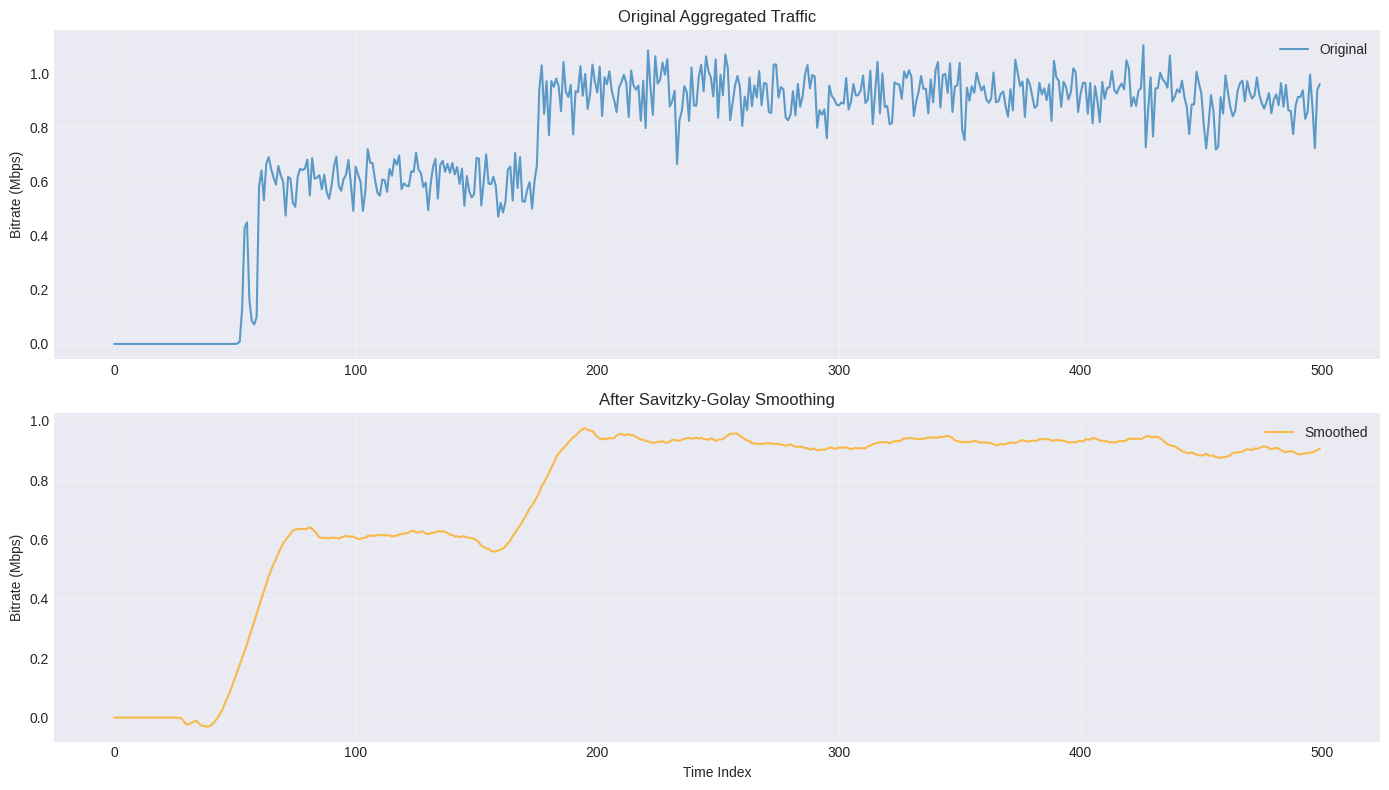

In [12]:
# Visualize effect of smoothing
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Original data
subset_idx = slice(0, 500)
axes[0].plot(aggregated_data.iloc[subset_idx]["dl_brate"] / 1e6, alpha=0.7, label="Original")
axes[0].set_title("Original Aggregated Traffic")
axes[0].set_ylabel("Bitrate (Mbps)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After smoothing (denormalize for visualization)
smoothed_denorm = preprocessor.inverse_normalize(result["processed_data"]["dl_brate"].values)
axes[1].plot(smoothed_denorm[subset_idx] / 1e6, alpha=0.7, label="Smoothed", color="orange")
axes[1].set_title("After Savitzky-Golay Smoothing")
axes[1].set_xlabel("Time Index")
axes[1].set_ylabel("Bitrate (Mbps)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Create Sequences for Training

Create input-output sequences for time series prediction.

In [13]:
# Configuration
INPUT_LENGTH = 96  # Historical window
OUTPUT_LENGTH = 96  # Prediction horizon
BATCH_SIZE = 32
STRIDE = 1  # Sliding window stride

print("Sequence configuration:")
print(f"  Input length (I): {INPUT_LENGTH}")
print(f"  Output length (O): {OUTPUT_LENGTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Stride: {STRIDE}")

Sequence configuration:
  Input length (I): 96
  Output length (O): 96
  Batch size: 32
  Stride: 1


In [14]:
# Create sequences for training
X_train, y_train = aggregator.create_sequences(
    data=train_data,
    input_length=INPUT_LENGTH,
    output_length=OUTPUT_LENGTH,
    target_column="dl_brate",
    feature_columns=["dl_brate"],
    stride=STRIDE,
)

X_val, y_val = aggregator.create_sequences(
    data=val_data,
    input_length=INPUT_LENGTH,
    output_length=OUTPUT_LENGTH,
    target_column="dl_brate",
    feature_columns=["dl_brate"],
    stride=STRIDE,
)

X_test, y_test = aggregator.create_sequences(
    data=test_data,
    input_length=INPUT_LENGTH,
    output_length=OUTPUT_LENGTH,
    target_column="dl_brate",
    feature_columns=["dl_brate"],
    stride=STRIDE,
)

print("=== Sequence Shapes ===")
print(f"X_train: {X_train.shape} (samples, input_length, features)")
print(f"y_train: {y_train.shape} (samples, output_length)")
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

=== Sequence Shapes ===
X_train: (156160, 96, 1) (samples, input_length, features)
y_train: (156160, 96) (samples, output_length)
X_val: (51926, 96, 1)
y_val: (51926, 96)
X_test: (51926, 96, 1)
y_test: (51926, 96)


In [15]:
# Create PyTorch datasets and dataloaders
train_dataset = TrafficDataset(X_train, y_train)
val_dataset = TrafficDataset(X_val, y_val)
test_dataset = TrafficDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Created dataloaders:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Created dataloaders:
  Train batches: 4880
  Val batches: 1623
  Test batches: 1623


## 5. Model Training

Train Autoformer and baseline models.

### 5.1 Train Autoformer

In [16]:
# Initialize Autoformer
autoformer = AutoformerPredictor(
    input_length=INPUT_LENGTH,
    output_length=OUTPUT_LENGTH,
    num_features=1,
    d_model=512,
    n_heads=8,
    e_layers=2,
    d_layers=1,
    d_ff=2048,
    dropout=0.1,
)

print("Autoformer initialized")
print(f"Device: {autoformer.device}")

✓ Initialized real Autoformer with:
  - Context length: 96
  - Prediction length: 96
  - Model dimension: 512
  - Encoder layers: 2, Decoder layers: 1
  - Attention heads: 8
  - Moving average window: 25
  - Auto-correlation factor: 3
  - Device: cuda
Autoformer initialized
Device: cuda


In [17]:
# Train Autoformer
print("Training Autoformer...")
autoformer_history = autoformer.train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    learning_rate=1e-4,
    early_stopping_patience=3,
    verbose=True,
)

print("\nTraining completed!")

Training Autoformer...


Epoch 1/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [03:46<00:00, 21.51it/s]


Epoch 1: Train Loss = 0.153361, Val Loss = 0.000153


Epoch 2/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [03:47<00:00, 21.44it/s]


Epoch 2: Train Loss = 0.165935, Val Loss = 0.000118


...

Epoch 3: Train Loss = 0.137787, Val Loss = 0.001751


Epoch 4/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [03:47<00:00, 21.42it/s]


Epoch 4: Train Loss = 0.145409, Val Loss = 0.000280


Epoch 5/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [03:47<00:00, 21.43it/s]


Epoch 5: Train Loss = 0.135925, Val Loss = 0.000863
Early stopping at epoch 5

Training completed!


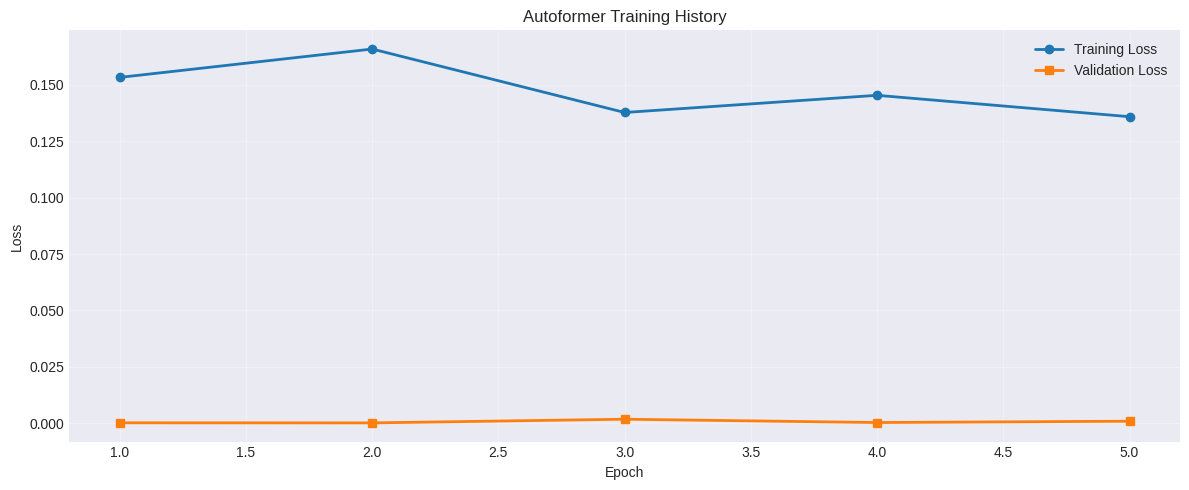

In [18]:
# Plot training history
visualizer.plot_training_history(history=autoformer_history, title="Autoformer Training History")

### 5.2 Train LSTM Baseline

In [19]:
# Initialize LSTM
lstm = LSTMPredictor(
    input_length=INPUT_LENGTH, output_length=OUTPUT_LENGTH, num_features=1, hidden_dim=128, num_layers=2, dropout=0.2
)

print("LSTM initialized")

LSTM initialized


In [20]:
# Train LSTM
print("Training LSTM...")
lstm_history = lstm.train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    learning_rate=1e-3,
    early_stopping_patience=3,
    verbose=True,
)

print("\nLSTM training completed!")

Training LSTM...


Epoch 1/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [00:12<00:00, 377.36it/s]


Epoch 1: Train Loss = 0.180268, Val Loss = 0.001087


Epoch 2/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [00:12<00:00, 379.57it/s]


Epoch 2: Train Loss = 0.143227, Val Loss = 0.000407


...

Epoch 4: Train Loss = 0.205830, Val Loss = 0.000080


Epoch 5/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [00:12<00:00, 380.77it/s]


Epoch 5: Train Loss = 0.106764, Val Loss = 0.000644


Epoch 6/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4880/4880 [00:12<00:00, 380.77it/s]


Epoch 6: Train Loss = 0.156135, Val Loss = 0.000053
Early stopping at epoch 6

LSTM training completed!


### 5.3 Initialize Simple Baselines

In [21]:
# Initialize simple baseline models (no training required)
persistence = PersistenceModel(output_length=OUTPUT_LENGTH)
moving_avg = MovingAverageModel(window_size=10, output_length=OUTPUT_LENGTH)

print("Baseline models initialized:")
print("  - Persistence Model")
print("  - Moving Average Model")

Baseline models initialized:
  - Persistence Model
  - Moving Average Model


## 6. Model Evaluation

Clear memory before running predictions

In [22]:
import gc

import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print("✓ GPU cache cleared")

✓ GPU cache cleared


Evaluate all models on the test set

In [23]:
# Make predictions on test set
print("Making predictions on test set...")

autoformer_pred = autoformer.predict(X_test)
lstm_pred = lstm.predict(X_test)
persistence_pred = persistence.predict(X_test)
moving_avg_pred = moving_avg.predict(X_test)

print("Predictions completed!")
print(f"Prediction shape: {autoformer_pred.shape}")

Making predictions on test set...
Predictions completed!
Prediction shape: (51926, 96)


In [24]:
# Flatten predictions for metric computation
y_test_flat = y_test.flatten()
autoformer_pred_flat = autoformer_pred.reshape(-1)
lstm_pred_flat = lstm_pred.reshape(-1)
persistence_pred_flat = persistence_pred.reshape(-1)
moving_avg_pred_flat = moving_avg_pred.reshape(-1)

# Compute metrics for all models
metrics = PredictionMetrics()

predictions_dict = {
    "Autoformer": autoformer_pred_flat,
    "LSTM": lstm_pred_flat,
    "Persistence": persistence_pred_flat,
    "Moving Average": moving_avg_pred_flat,
}

results = metrics.compare_models(y_test_flat, predictions_dict)

# Display results
results_df = pd.DataFrame(results).T
results_df = results_df[["mse", "mae", "rmse", "r2"]]
results_df = results_df.sort_values("mse")

print("\n=== Model Comparison ===")
print(results_df.to_string())
print("\n(Lower MSE/MAE/RMSE is better, higher R² is better)")


=== Model Comparison ===
                     mse       mae      rmse        r2
Persistence     0.163905  0.045293  0.404851  0.910037
Moving Average  0.177825  0.048790  0.421693  0.902396
LSTM            0.212321  0.092068  0.460783  0.883462
Autoformer      1.908354  0.338712  1.381432 -0.047448

(Lower MSE/MAE/RMSE is better, higher R² is better)


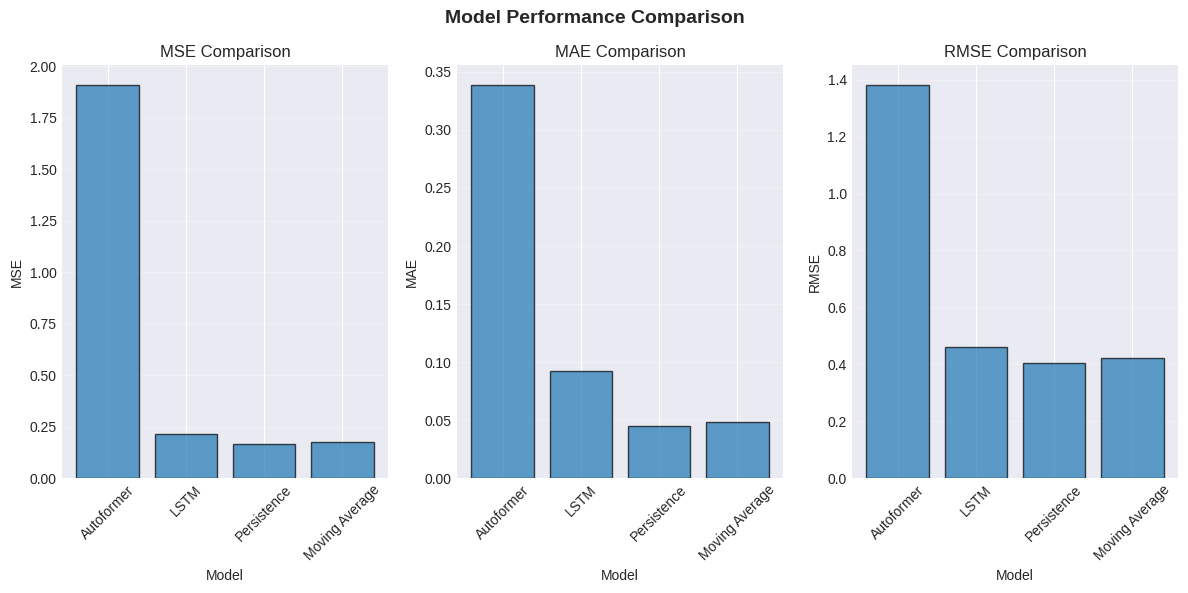

In [25]:
# Visualize metrics comparison
visualizer.plot_metrics_comparison(
    metrics_dict=results, metrics_to_plot=["mse", "mae", "rmse"], title="Model Performance Comparison"
)

## 7. Residual Analysis

Analyze residuals to check for systematic errors.

Downsampling residuals from 4984896 to 10000 for plotting performance


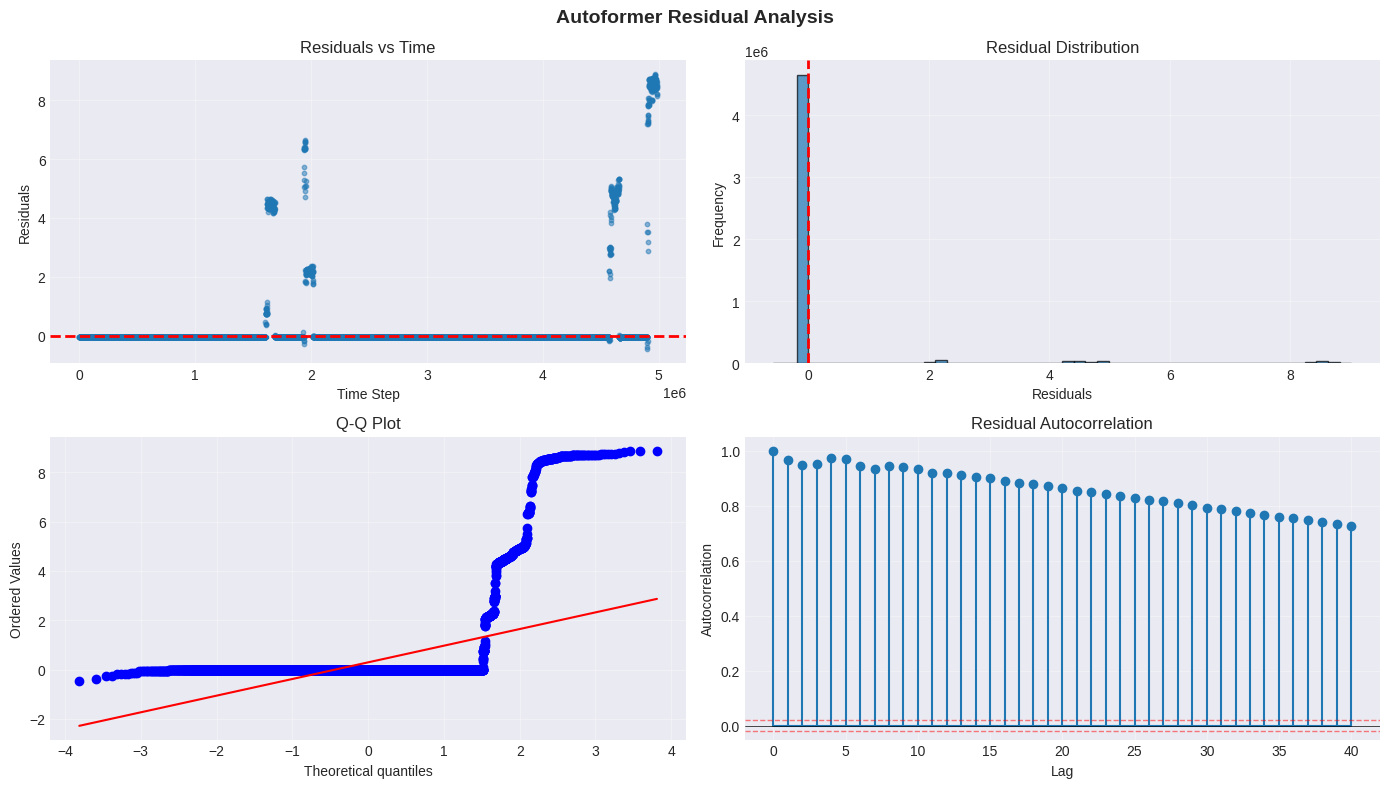

Mean residual: 0.293962
Std residual: 1.349793
Min/Max: [-0.5772, 9.0116]


In [26]:
# Compute residuals for Autoformer
autoformer_residuals = metrics.compute_residuals(y_test_flat, autoformer_pred_flat)

# Plot residuals
visualizer.plot_residuals(residuals=autoformer_residuals, title="Autoformer Residual Analysis")

# Print statistics instead of plotting
print(f"Mean residual: {autoformer_residuals.mean():.6f}")
print(f"Std residual: {autoformer_residuals.std():.6f}")
print(f"Min/Max: [{autoformer_residuals.min():.4f}, {autoformer_residuals.max():.4f}]")

In [27]:
# Residual statistics
residual_stats = metrics.residual_statistics(autoformer_residuals)

print("=== Autoformer Residual Statistics ===")
for key, value in residual_stats.items():
    print(f"{key:10s}: {value:.6f}")

print("\nInterpretation:")
print(f"  Mean close to 0: {'✓' if abs(residual_stats['mean']) < 0.01 else '✗'}")
print(f"  Symmetric distribution: {'✓' if abs(residual_stats['median']) < 0.01 else '✗'}")

=== Autoformer Residual Statistics ===
mean      : 0.293962
std       : 1.349793
min       : -0.577164
max       : 9.011607
median    : -0.023636

Interpretation:
  Mean close to 0: ✗
  Symmetric distribution: ✗


## 8. Prediction Visualization

Visualize predictions vs ground truth.

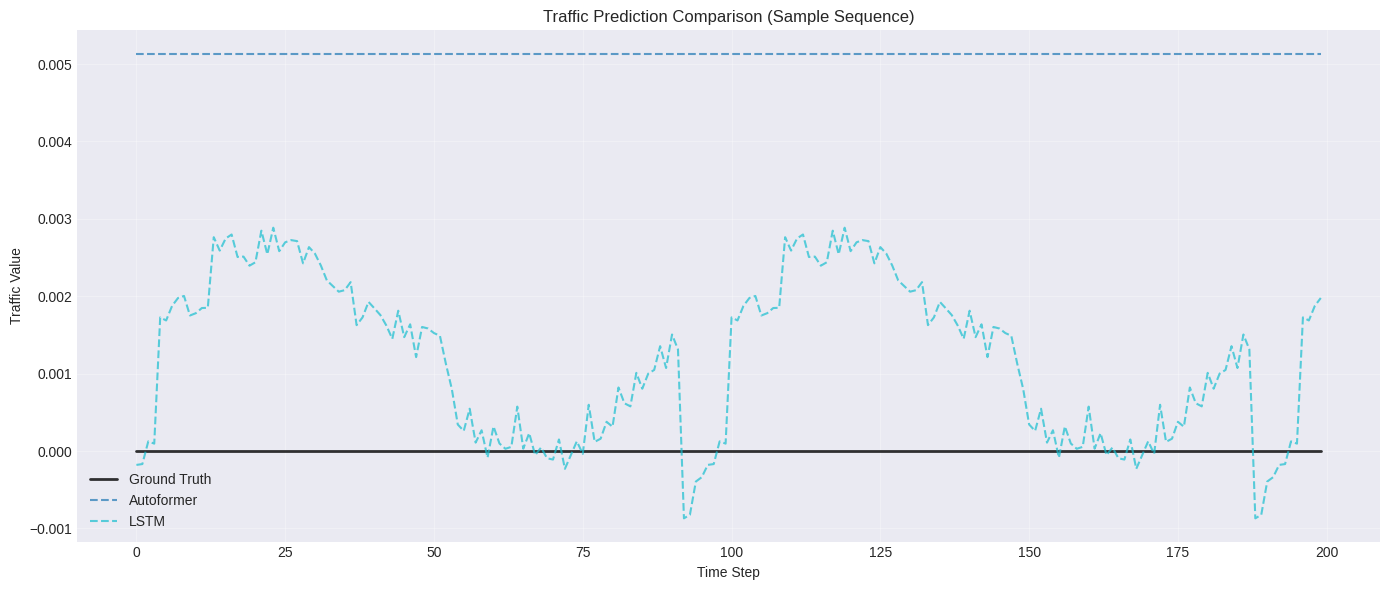

In [28]:
# Plot predictions for a sample sequence
sample_idx = 100
sample_length = 200

# Denormalize for visualization
y_true_denorm = preprocessor.inverse_normalize(y_test_flat[sample_idx : sample_idx + sample_length])
autoformer_denorm = preprocessor.inverse_normalize(autoformer_pred_flat[sample_idx : sample_idx + sample_length])
lstm_denorm = preprocessor.inverse_normalize(lstm_pred_flat[sample_idx : sample_idx + sample_length])

# Convert to Mbps
y_true_mbps = y_true_denorm / 1e6
autoformer_mbps = autoformer_denorm / 1e6
lstm_mbps = lstm_denorm / 1e6

visualizer.plot_comparison(
    y_true=y_true_mbps,
    predictions_dict={"Autoformer": autoformer_mbps, "LSTM": lstm_mbps},
    title="Traffic Prediction Comparison (Sample Sequence)",
)

## 9. Save Results and Models

In [29]:
# Create results directory
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

# Save metrics
results_df.to_csv(results_dir / "model_comparison.csv")
print(f"Saved metrics to {results_dir / 'model_comparison.csv'}")

# Save models
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

autoformer.save_model(str(models_dir / "autoformer.pth"))
print(f"Saved Autoformer to {models_dir / 'autoformer.pth'}")

# Save preprocessor scaler
import pickle

with open(models_dir / "scaler.pkl", "wb") as f:
    pickle.dump(preprocessor.scaler, f)
print(f"Saved scaler to {models_dir / 'scaler.pkl'}")

Saved metrics to /home/andang/Documents/UCLAB/projects/O-RAN-DW/traffic-prediction/results/model_comparison.csv
✓ Model saved to /home/andang/Documents/UCLAB/projects/O-RAN-DW/traffic-prediction/models/autoformer.pth
Saved Autoformer to /home/andang/Documents/UCLAB/projects/O-RAN-DW/traffic-prediction/models/autoformer.pth
Saved scaler to /home/andang/Documents/UCLAB/projects/O-RAN-DW/traffic-prediction/models/scaler.pkl


## 10. Summary and Next Steps

### Key Findings

1. **Model Performance**: Autoformer vs baselines
2. **Residual Analysis**: Check for systematic bias
3. **Prediction Quality**: Visual inspection of forecasts

### Next Steps

1. **Experiment with different prediction horizons** (96, 192, 336, 720)
2. **Incorporate multi-BS prediction** (all 4 base stations)
3. **Add slice-aware features** (traffic class, scheduling policy, RBG allocation)
4. **Test on different scenarios** (rome_static_close, rome_static_far, rome_slow_close)
5. **Implement threshold-based optimization** (Traffic Steering xApp, Cell Sleeping rApp)
6. **Compare with original thuml/Autoformer** if HuggingFace version differs

### References

- Habib et al. (2024): Transformer-Based Wireless Traffic Prediction
- Wu et al.: Autoformer Architecture
- Bonati et al. (2021): O-RAN Dataset Description